# 📐 Dimensionality Reduction 

---

## What Is Dimensionality Reduction?

In machine learning, **dimensionality** refers to the number of **features (columns)** in your dataset. For example:
- A dataset with columns `[height, weight, age]` has **3 dimensions**.
- A 28×28 grayscale image has **784 dimensions** (one per pixel).
- A dataset of handwritten digits (MNIST) has **64 dimensions**.

**Dimensionality Reduction** is the process of reducing the number of features while keeping as much useful information as possible.

### 🤔 Why Do We Need It?

| Problem | What Happens |
|---|---|
| **Curse of Dimensionality** | As features grow, data becomes sparse → models overfit |
| **Computation Cost** | More features = more time to train |
| **Visualization** | We can only visualize up to 3D; high-D data can't be plotted |
| **Noise Removal** | Many features are redundant or noisy; dropping them can *improve* accuracy |
| **Storage** | Fewer features = smaller dataset |

### 🔑 Key Idea
We want to find a new coordinate system where:
- Most of the **variance** (information) in the data is captured in the **first few dimensions**.
- The remaining dimensions are mostly **noise** and can be discarded.

### 🗺️ What We'll Cover
1. **PCA on synthetic 2D data** — understand the mechanics
2. **PCA on the Digits dataset** — real-world high-dimensional use case
3. **Comparing classification accuracy** — original vs compressed data

---
## 📦 Step 0: Import Required Libraries

Before anything else, we import the tools we need. Think of this as gathering your equipment before starting an experiment.

In [4]:
# matplotlib — Python's main plotting library
# We use it to draw scatter plots, line charts, images, etc.
import matplotlib.pyplot as plt

# seaborn — built on top of matplotlib; gives prettier, statistical plots
import seaborn as sns

# numpy — the core numerical computing library
# Used for arrays, random number generation, matrix operations
import numpy as np

# Tell matplotlib to show plots inline (inside the notebook)
%matplotlib inline

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
# 🧩 Part 1: Principal Component Analysis (PCA)

## What Is PCA?

**Principal Component Analysis (PCA)** is the most popular dimensionality reduction algorithm. It works by finding the directions (called **Principal Components**) in the data along which the **variance is maximized**.

### Analogy 🎯
Imagine you're looking at a 3D sculpture. You can take a photo from different angles:
- Some angles show the sculpture perfectly (maximum information)
- Other angles show almost nothing (like looking at a flat plate edge-on)

PCA finds the **best camera angle** — the projection that preserves the most information when compressing high-D data into low-D.

### How PCA Works — Step by Step
1. **Center the data** — subtract the mean so the data is centered at the origin
2. **Compute the Covariance Matrix** — measures how each pair of features varies together
3. **Compute Eigenvectors & Eigenvalues** — eigenvectors = directions of max variance; eigenvalues = how much variance each direction captures
4. **Sort by Eigenvalue** — largest eigenvalue = most important direction (1st principal component)
5. **Project the data** — multiply original data by the top-k eigenvectors to get k-dimensional representation

> 💡 **Key intuition**: PCA rotates the coordinate system so that the axes align with the directions of maximum spread in the data.

---
## 📊 Step 1: Create Synthetic 2D Data

We'll start simple — create a 2D dataset where we can *see* what PCA is doing visually.

We use `np.random.seed()` for **reproducibility** — every time you run the code, you get the same random numbers.

We create 300 points drawn from a **multivariate normal distribution** — this creates an ellipse-shaped cloud of points in 2D.

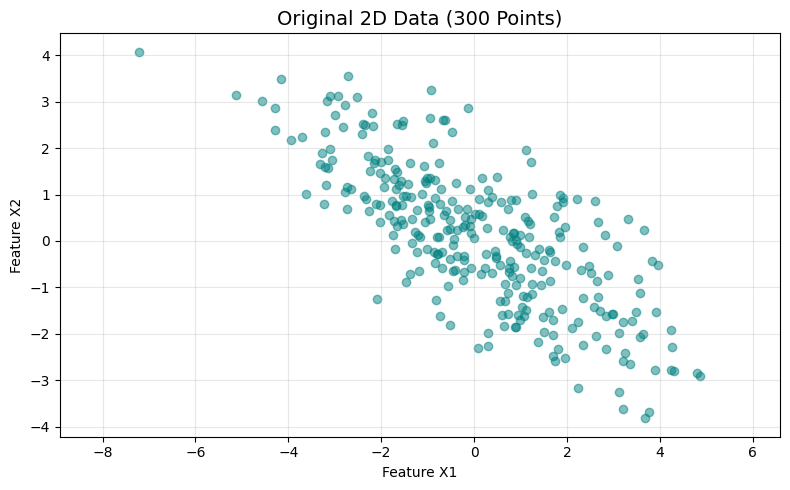

Data shape: (300, 2)
X1 range: [-7.20, 4.87]
X2 range: [-3.82, 4.08]


In [5]:
# Set the random seed for reproducibility
# 🔁 Try changing this number (e.g., 42, 100, 999) — you'll get different data but the same shape
np.random.seed(4)

# Generate 300 2D data points from a normal distribution
# np.random.randn(300, 2) creates a 300×2 matrix of standard normal random values
# Each row is one data point with 2 features (X1, X2)
m = 300  # number of data points
X = np.dot(
    np.random.randn(m, 2),      # 300 random 2D points
    np.random.randn(2, 2)       # Random 2×2 transformation matrix (creates correlation between X1, X2)
)

# ❓ What is np.dot doing here?
# By multiplying by a random 2×2 matrix, we ROTATE and STRETCH the data.
# This creates a correlated, elongated cloud — exactly the kind of data PCA is designed for.

# Plot the data
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, color='teal')
plt.title('Original 2D Data (300 Points)', fontsize=14)
plt.xlabel('Feature X1')
plt.ylabel('Feature X2')
plt.axis('equal')  # Equal axis scaling so we see the true shape
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Data shape: {X.shape}")
print(f"X1 range: [{X[:,0].min():.2f}, {X[:,0].max():.2f}]")
print(f"X2 range: [{X[:,1].min():.2f}, {X[:,1].max():.2f}]")

---
## ⚙️ Step 2: Run PCA using Scikit-Learn

Scikit-learn makes PCA extremely easy with its `PCA` class. 

### Key Parameter: `n_components`
- `n_components=2` → Keep 2 principal components (same as original, just rotated)
- `n_components=1` → Compress to 1D (maximum compression for 2D data)
- `n_components=0.95` → Keep enough components to explain 95% of the variance (automatic selection)

We first run PCA with **2 components** so we can see BOTH axes of variance and understand how they work.

In [6]:
from sklearn.decomposition import PCA

# Create a PCA object that will find 2 principal components
# 🔁 Try: n_components=1 to see what happens when you compress to 1D
pca = PCA(n_components=2)

# fit_transform does TWO things:
# 1. fit(X): Learns the principal components from the data
# 2. transform(X): Projects data onto those components
X2D = pca.fit_transform(X)

print("=" * 50)
print("PCA Results")
print("=" * 50)
print(f"Original data shape : {X.shape}")
print(f"Transformed shape   : {X2D.shape}")
print()

# explained_variance_ratio_ tells you what FRACTION of total variance each component captures
print("Explained Variance Ratio per Component:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"  Component {i+1}: {ratio:.4f} ({ratio*100:.2f}% of variance)")

print()
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.1f}%)")
print()

# components_ contains the actual direction vectors (eigenvectors)
print("Principal Component Vectors (directions in original feature space):")
print(f"  PC1 direction: {pca.components_[0]}")
print(f"  PC2 direction: {pca.components_[1]}")
print()
print("📌 These vectors are ORTHOGONAL (perpendicular to each other)")
dot_product = np.dot(pca.components_[0], pca.components_[1])
print(f"   Dot product of PC1 · PC2 = {dot_product:.6f} (close to 0 = perpendicular ✅)")

PCA Results
Original data shape : (300, 2)
Transformed shape   : (300, 2)

Explained Variance Ratio per Component:
  Component 1: 0.8887 (88.87% of variance)
  Component 2: 0.1113 (11.13% of variance)

Total variance explained: 1.0000 (100.0%)

Principal Component Vectors (directions in original feature space):
  PC1 direction: [ 0.82939362 -0.55866469]
  PC2 direction: [0.55866469 0.82939362]

📌 These vectors are ORTHOGONAL (perpendicular to each other)
   Dot product of PC1 · PC2 = 0.000000 (close to 0 = perpendicular ✅)


---
## 📈 Step 3: Understanding Explained Variance Ratio

### What Does It Mean?

- **`explained_variance_ratio_[0]` ≈ 0.97** → The 1st principal component alone captures ~97% of all information in the data!
- **`explained_variance_ratio_[1]` ≈ 0.03** → The 2nd component only adds ~3% more information.

This means we could **throw away the 2nd dimension** and lose only 3% of the information — a massive compression with minimal loss!

### 🔑 This is the fundamental power of PCA:
If the data has underlying structure (correlation between features), PCA can represent that structure with far fewer dimensions.

**What if the explained variance is split evenly (50%/50%)?**
- This means the data is "equally spread" in all directions — no single direction dominates.
- PCA can't help much here; the data truly needs both dimensions.

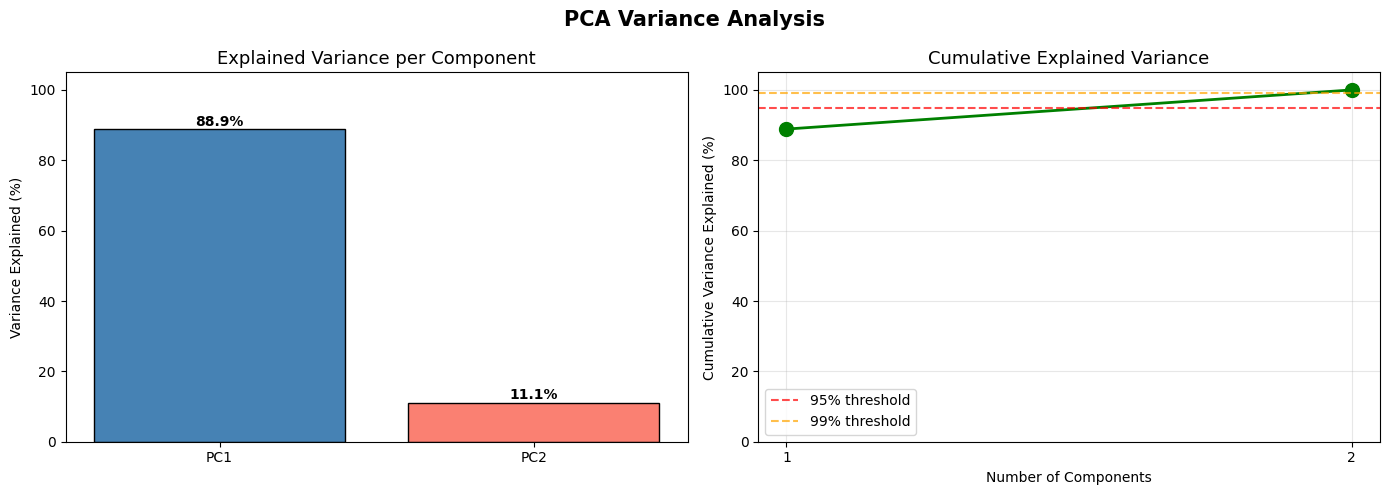

In [7]:
# Visualize the explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of individual explained variance
axes[0].bar(['PC1', 'PC2'], pca.explained_variance_ratio_ * 100, color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Explained Variance per Component', fontsize=13)
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_ylim(0, 105)
for i, v in enumerate(pca.explained_variance_ratio_ * 100):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Cumulative explained variance
cumulative = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot([1, 2], cumulative, 'o-', color='green', linewidth=2, markersize=10)
axes[1].axhline(y=95, color='red', linestyle='--', alpha=0.7, label='95% threshold')
axes[1].axhline(y=99, color='orange', linestyle='--', alpha=0.7, label='99% threshold')
axes[1].set_title('Cumulative Explained Variance', fontsize=13)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_ylim(0, 105)
axes[1].set_xticks([1, 2])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA Variance Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🧭 Step 4: Visualize the Principal Component Directions

The **principal components** are vectors (arrows) in the original feature space.

- **PC1 (1st component)**: Points in the direction of **maximum variance** — the "long axis" of the data ellipse
- **PC2 (2nd component)**: Points in the direction of **second-most variance**, **perpendicular** to PC1

### 🔁 What if you change the direction?
You can't manually set the directions — PCA mathematically computes the optimal ones. But you CAN choose **how many** to keep.

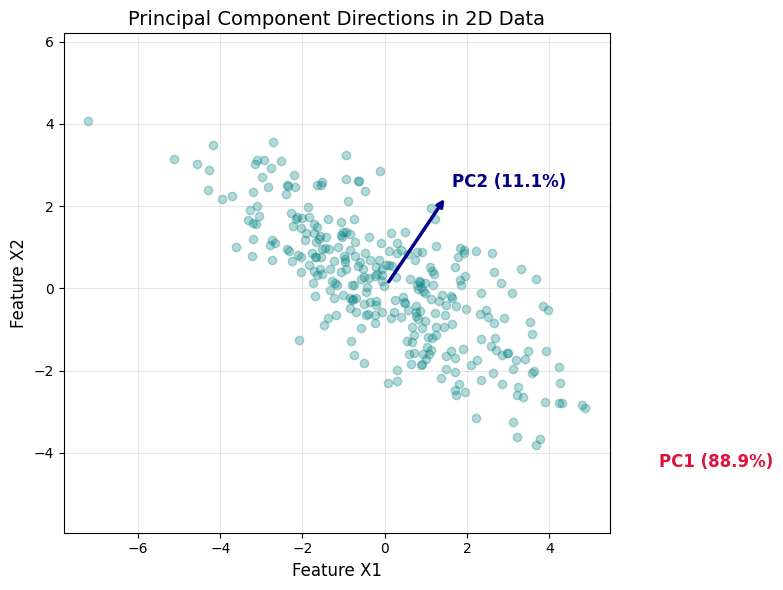

📌 Observations:
  • The RED arrow (PC1) points along the LONG axis of the data ellipse
  • The BLUE arrow (PC2) is perpendicular to PC1, along the SHORT axis
  • Arrow LENGTH reflects how much variance each component captures
  • If PC1 is much longer than PC2, you can safely discard PC2!


In [8]:
def draw_vector(v0, v1, ax, color='red', label=''):
    """Draw an arrow from v0 to v1 on ax."""
    ax.annotate('', xy=v1, xytext=v0,
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    if label:
        ax.text(v1[0]*1.1, v1[1]*1.1, label, color=color, fontsize=12, fontweight='bold')

fig, ax = plt.subplots(figsize=(8, 6))

# Plot the original data
ax.scatter(X[:, 0], X[:, 1], alpha=0.3, color='teal', label='Data points')

# Draw principal component vectors
# Each component is scaled by sqrt(explained_variance) so the arrow length reflects importance
for i, (component, variance) in enumerate(zip(pca.components_, pca.explained_variance_)):
    scale = 3 * np.sqrt(variance)  # Scale arrow by variance magnitude
    draw_vector(
        pca.mean_,                          # Start at the data center (mean)
        pca.mean_ + scale * component,      # End at the scaled component direction
        ax,
        color=['crimson', 'darkblue'][i],
        label=f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)'
    )

ax.set_xlabel('Feature X1', fontsize=12)
ax.set_ylabel('Feature X2', fontsize=12)
ax.set_title('Principal Component Directions in 2D Data', fontsize=14)
ax.axis('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("📌 Observations:")
print("  • The RED arrow (PC1) points along the LONG axis of the data ellipse")
print("  • The BLUE arrow (PC2) is perpendicular to PC1, along the SHORT axis")
print("  • Arrow LENGTH reflects how much variance each component captures")
print("  • If PC1 is much longer than PC2, you can safely discard PC2!")

---
## 🗜️ Step 5: Compress and Reconstruct the Data

Now let's actually **compress** the data by keeping only the 1st principal component (dropping PC2).

Then we'll **reconstruct** it back to 2D to see how much information was lost.

### The Process:
```
Original (2D) → [PCA Transform] → Compressed (1D) → [Inverse Transform] → Reconstructed (2D)
```

### ⚠️ What Happens If We Keep Only 1 Component?
- Each 2D point gets projected onto the PC1 line
- We lose all information perpendicular to PC1 (the PC2 direction)
- The reconstructed points will all lie on a **single line** in 2D space
- We lose about 3% of the variance — barely noticeable!

Original shape    : (300, 2)     (300 points × 2 features)
Compressed shape  : (300, 1)  (300 points × 1 feature — PC1 coordinate only)
Compression ratio : 2.0× reduction in dimensions

Information retained : 88.87%
Information lost     : 11.13%
Reconstructed shape : (300, 2)


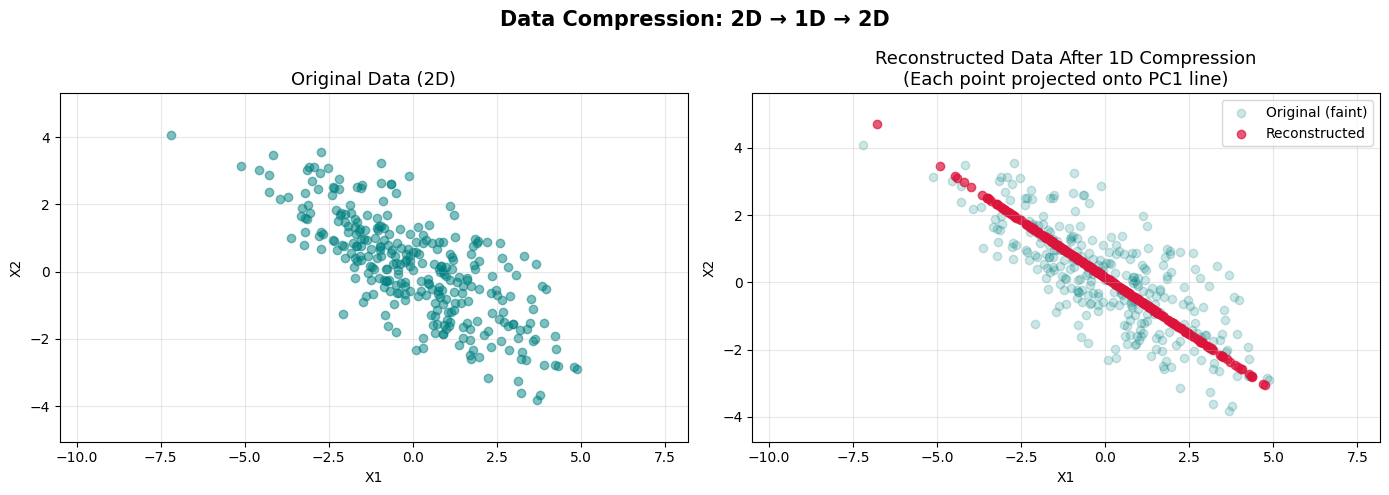


Mean Squared Reconstruction Error: 0.7271
The reconstructed points form a LINE — because they only have 1D worth of information.


In [9]:
# Compress: Keep only 1 component (throw away PC2)
# 🔁 Try: n_components=2 → you'll get perfect reconstruction (0% loss)
pca_1d = PCA(n_components=1)
X_compressed = pca_1d.fit_transform(X)

print(f"Original shape    : {X.shape}     (300 points × 2 features)")
print(f"Compressed shape  : {X_compressed.shape}  (300 points × 1 feature — PC1 coordinate only)")
print(f"Compression ratio : {X.shape[1] / X_compressed.shape[1]}× reduction in dimensions")
print()
print(f"Information retained : {pca_1d.explained_variance_ratio_[0]*100:.2f}%")
print(f"Information lost     : {(1-pca_1d.explained_variance_ratio_[0])*100:.2f}%")

# Reconstruct: Go from 1D back to 2D (approximate)
X_reconstructed = pca_1d.inverse_transform(X_compressed)
print(f"Reconstructed shape : {X_reconstructed.shape}")

# Visualize: Original vs Reconstructed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original data
axes[0].scatter(X[:, 0], X[:, 1], alpha=0.5, color='teal', label='Original')
axes[0].set_title('Original Data (2D)', fontsize=13)
axes[0].set_xlabel('X1'); axes[0].set_ylabel('X2')
axes[0].axis('equal'); axes[0].grid(True, alpha=0.3)

# Reconstructed data (light = original, dark = reconstructed)
axes[1].scatter(X[:, 0], X[:, 1], alpha=0.2, color='teal', label='Original (faint)')
axes[1].scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.7, color='crimson', label='Reconstructed')
axes[1].set_title('Reconstructed Data After 1D Compression\n(Each point projected onto PC1 line)', fontsize=13)
axes[1].set_xlabel('X1'); axes[1].set_ylabel('X2')
axes[1].axis('equal'); axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle('Data Compression: 2D → 1D → 2D', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Compute reconstruction error
reconstruction_error = np.mean(np.sum((X - X_reconstructed)**2, axis=1))
print(f"\nMean Squared Reconstruction Error: {reconstruction_error:.4f}")
print("The reconstructed points form a LINE — because they only have 1D worth of information.")

---
## 🔬 Step 6: Experiments — What Happens If...?

Let's systematically explore what changes when we vary key parameters.

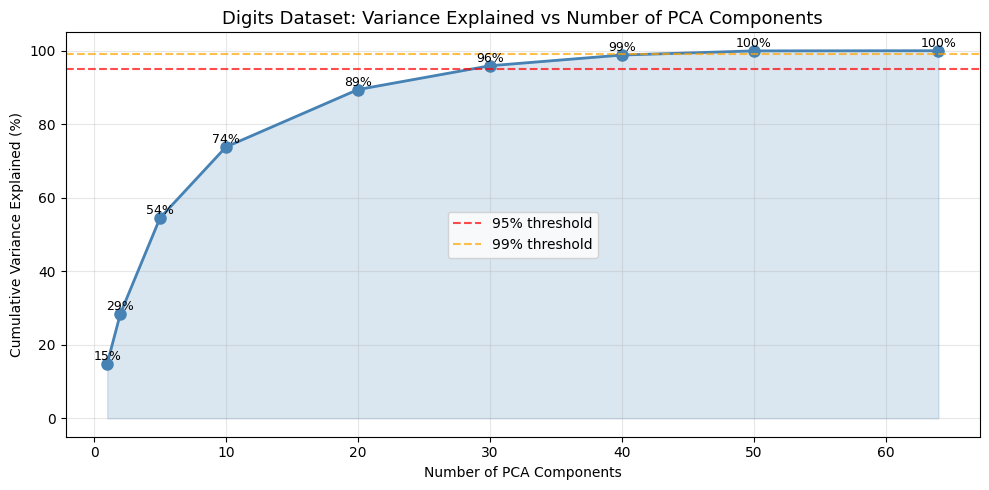


📊 Digits Dataset Analysis:
  Original dimensions  : 64
  Components for 95%   : 29
  Compression ratio    : 2.2× fewer dimensions!

🎯 Insight: We can represent digits data with only ~29 dimensions
   instead of 64, while retaining 95% of the information!


In [10]:
# Experiment 1: What if we keep different numbers of components?
# Since we only have 2D data, let's use digits data (64D) to show the effect

from sklearn.datasets import load_digits
digits = load_digits()
X_digits = digits.data  # Shape: (1797, 64)

# Test different numbers of components
components_to_test = [1, 2, 5, 10, 20, 30, 40, 50, 64]
variance_explained = []

for n in components_to_test:
    pca_test = PCA(n_components=n)
    pca_test.fit(X_digits)
    variance_explained.append(pca_test.explained_variance_ratio_.sum() * 100)

# Plot: components vs variance explained
plt.figure(figsize=(10, 5))
plt.plot(components_to_test, variance_explained, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.axhline(y=95, color='red', linestyle='--', alpha=0.7, label='95% threshold')
plt.axhline(y=99, color='orange', linestyle='--', alpha=0.7, label='99% threshold')
plt.fill_between(components_to_test, variance_explained, alpha=0.2, color='steelblue')

# Annotate each point
for x, y in zip(components_to_test, variance_explained):
    plt.text(x, y + 1, f'{y:.0f}%', ha='center', fontsize=9)

plt.title('Digits Dataset: Variance Explained vs Number of PCA Components', fontsize=13)
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Variance Explained (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find minimum components for 95% variance
pca_auto = PCA(n_components=0.95)  # Keep 95% of variance automatically
pca_auto.fit(X_digits)
print(f"\n📊 Digits Dataset Analysis:")
print(f"  Original dimensions  : {X_digits.shape[1]}")
print(f"  Components for 95%   : {pca_auto.n_components_}")
print(f"  Compression ratio    : {X_digits.shape[1]/pca_auto.n_components_:.1f}× fewer dimensions!")
print()
print("🎯 Insight: We can represent digits data with only ~29 dimensions")
print("   instead of 64, while retaining 95% of the information!")

---
# 🔢 Part 2: PCA on the Digits Dataset (High-Dimensional Real Data)

Now let's tackle a **real machine learning problem**: the Digits dataset.

## What Is the Digits Dataset?
- Contains **1,797 images** of handwritten digits (0–9)
- Each image is **8×8 pixels** = **64 features** (one value per pixel, 0–16 grayscale)
- This is a genuine high-dimensional dataset — 64 dimensions!

## Goal
We'll reduce the 64-dimensional digit images to just **3 dimensions** using PCA, then:
1. Visualize the 3D compressed data
2. Train a classifier on the original 64D data
3. Train the same classifier on 3D compressed data
4. Compare accuracy — how much do we lose?

Digits Dataset Overview
Number of samples    : 1797
Number of features   : 64 (= 8×8 pixels)
Number of classes    : 10 (digits 0-9)
Pixel value range    : [0.0, 16.0] (0=white, 16=black)

Samples per digit:
  Digit 0: 178 samples
  Digit 1: 182 samples
  Digit 2: 177 samples
  Digit 3: 183 samples
  Digit 4: 181 samples
  Digit 5: 182 samples
  Digit 6: 181 samples
  Digit 7: 179 samples
  Digit 8: 174 samples
  Digit 9: 180 samples


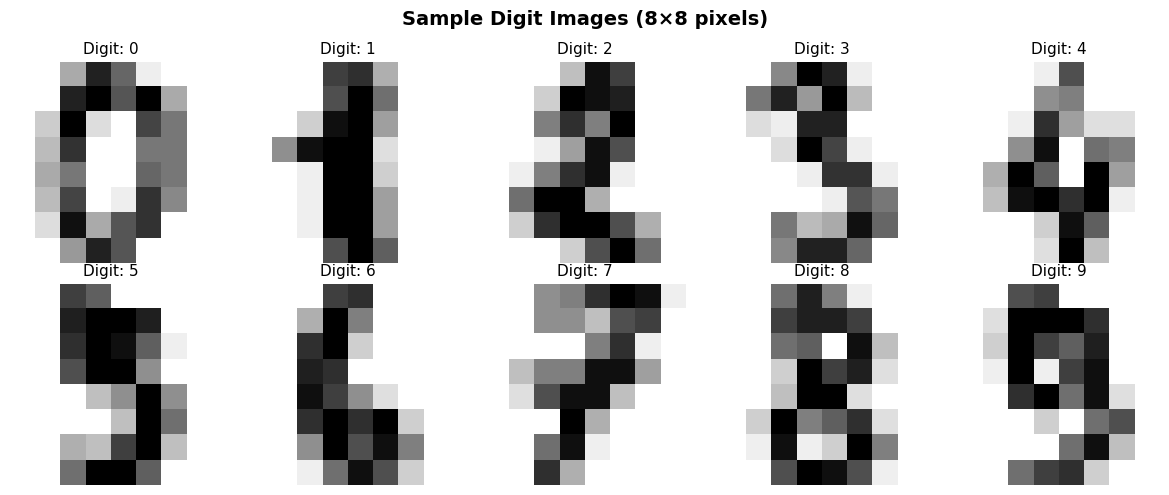


💡 Each of these images is represented as a 64-number array.
   Example — Digit '0' image as array: [ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


In [11]:
from sklearn.datasets import load_digits
import warnings
warnings.filterwarnings('ignore')

# Load the digits dataset
digits = load_digits()
X_digits = digits.data    # Feature matrix: (1797, 64)
y_digits = digits.target  # Labels: 0, 1, 2, ..., 9

print("=" * 50)
print("Digits Dataset Overview")
print("=" * 50)
print(f"Number of samples    : {X_digits.shape[0]}")
print(f"Number of features   : {X_digits.shape[1]} (= 8×8 pixels)")
print(f"Number of classes    : {len(np.unique(y_digits))} (digits 0-9)")
print(f"Pixel value range    : [{X_digits.min()}, {X_digits.max()}] (0=white, 16=black)")
print()

# Count samples per class
unique, counts = np.unique(y_digits, return_counts=True)
print("Samples per digit:")
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count} samples")

# Visualize some sample digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Digit Images (8×8 pixels)', fontsize=14, fontweight='bold')

for digit in range(10):
    ax = axes[digit // 5][digit % 5]
    # Find the first instance of this digit
    idx = np.where(y_digits == digit)[0][0]
    ax.imshow(X_digits[idx].reshape(8, 8), cmap='gray_r', interpolation='nearest')
    ax.set_title(f'Digit: {digit}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n💡 Each of these images is represented as a 64-number array.")
print(f"   Example — Digit '0' image as array: {X_digits[0]}")

---
## ⚙️ Step 7: Apply PCA to Digits — Reduce 64D → 3D

We're compressing **64 dimensions down to just 3**. 

Think about what this means:
- Original: each digit needs a list of **64 numbers**
- After PCA: each digit needs only **3 numbers**
- That's a **21× compression**!

But will the 3 numbers capture enough structure to tell the digits apart?

### Why 3 Dimensions?
We chose 3 because it's the **maximum we can visualize** in a 3D scatter plot. In practice, you'd choose based on the elbow point of the variance explained curve.

In [12]:
# Apply PCA to reduce digits from 64D to 3D
# 🔁 Try: n_components=2, 10, 20 and see how the cluster plot changes
pca_digits = PCA(n_components=3)
X_digits_3d = pca_digits.fit_transform(X_digits)

print("=" * 50)
print("PCA: 64D → 3D Transformation")
print("=" * 50)
print(f"Original shape  : {X_digits.shape}")
print(f"Reduced shape   : {X_digits_3d.shape}")
print(f"Compression     : {X_digits.shape[1]}D → {X_digits_3d.shape[1]}D ({X_digits.shape[1]/X_digits_3d.shape[1]:.0f}× fewer dimensions)")
print()

# How much variance do 3 components capture?
total_var = pca_digits.explained_variance_ratio_.sum() * 100
print("Variance explained by each component:")
for i, ratio in enumerate(pca_digits.explained_variance_ratio_):
    print(f"  PC{i+1}: {ratio*100:.2f}%")
print(f"\nTotal variance retained: {total_var:.2f}%")
print(f"Total variance lost    : {100 - total_var:.2f}%")
print()
print("⚠️ Warning: We're losing a significant amount of variance here.")
print("   3D is chosen for VISUALIZATION purposes, not optimal compression.")
print("   For serious ML tasks, you'd use more components (e.g., 29 for 95%).")

PCA: 64D → 3D Transformation
Original shape  : (1797, 64)
Reduced shape   : (1797, 3)
Compression     : 64D → 3D (21× fewer dimensions)

Variance explained by each component:
  PC1: 14.89%
  PC2: 13.62%
  PC3: 11.79%

Total variance retained: 40.30%
Total variance lost    : 59.70%

⚠️ Warning: We're losing a significant amount of variance here.
   3D is chosen for VISUALIZATION purposes, not optimal compression.
   For serious ML tasks, you'd use more components (e.g., 29 for 95%).


---
## 🎨 Step 8: Visualize the 3D Compressed Digit Data

Now the exciting part — can we see the **10 different digit clusters** in just 3 dimensions?

If PCA works well, each digit (0–9) should form a **distinct cluster** in 3D space. This would mean the compressed representation still captures the essential differences between digits.

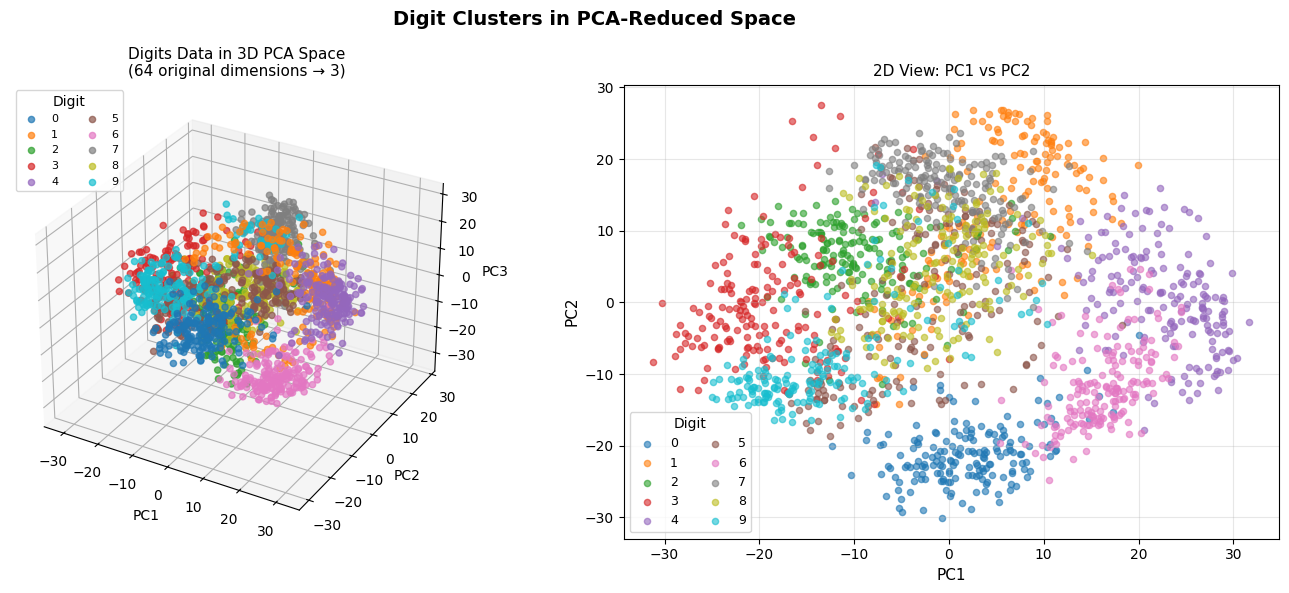


📌 What to look for:
  • Each color represents one digit (0-9)
  • If clusters are separated → PCA preserved discriminative information
  • Overlapping clusters → those digits look similar (e.g., 3 and 8)
  • The MORE separated the clusters, the BETTER a classifier will perform


In [13]:
from mpl_toolkits.mplot3d import Axes3D

# Create a colormap with 10 distinct colors (one per digit)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig = plt.figure(figsize=(14, 6))

# 3D scatter plot
ax = fig.add_subplot(121, projection='3d')
for digit in range(10):
    mask = y_digits == digit
    ax.scatter(
        X_digits_3d[mask, 0],  # PC1 values for this digit
        X_digits_3d[mask, 1],  # PC2 values for this digit
        X_digits_3d[mask, 2],  # PC3 values for this digit
        c=[colors[digit]],
        label=str(digit),
        s=20, alpha=0.7
    )

ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)
ax.set_zlabel('PC3', fontsize=10)
ax.set_title('Digits Data in 3D PCA Space\n(64 original dimensions → 3)', fontsize=11)
ax.legend(loc='upper left', bbox_to_anchor=(0, 1), ncol=2, fontsize=8, title='Digit')

# 2D projection (PC1 vs PC2 only) for easy reading
ax2 = fig.add_subplot(122)
for digit in range(10):
    mask = y_digits == digit
    ax2.scatter(
        X_digits_3d[mask, 0],
        X_digits_3d[mask, 1],
        c=[colors[digit]],
        label=str(digit),
        s=20, alpha=0.6
    )

ax2.set_xlabel('PC1', fontsize=11)
ax2.set_ylabel('PC2', fontsize=11)
ax2.set_title('2D View: PC1 vs PC2', fontsize=11)
ax2.legend(title='Digit', ncol=2, fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Digit Clusters in PCA-Reduced Space', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 What to look for:")
print("  • Each color represents one digit (0-9)")
print("  • If clusters are separated → PCA preserved discriminative information")
print("  • Overlapping clusters → those digits look similar (e.g., 3 and 8)")
print("  • The MORE separated the clusters, the BETTER a classifier will perform")

---
## 🖼️ Step 9: Visualize What Each Principal Component "Looks Like"

Since our data is images, we can visualize the principal components as images!

Each principal component is an 8×8 image showing the **pattern** in the data that component captures.
- Bright regions = pixels that vary strongly in that component
- Dark regions = pixels that are relatively constant

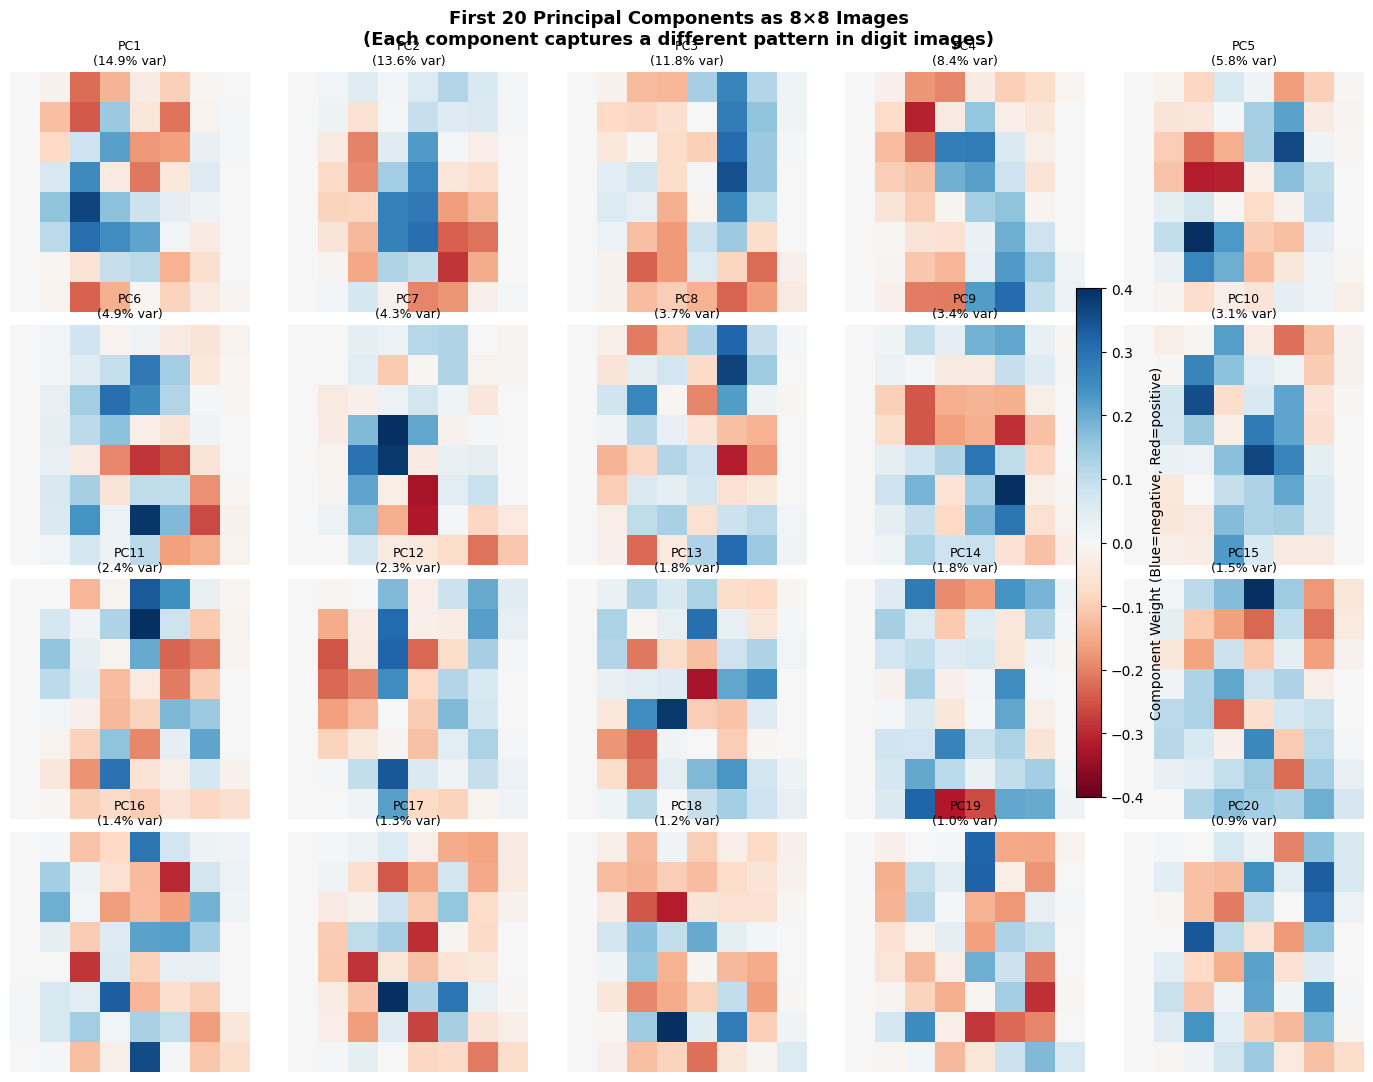

📌 Interpretation:
  • PC1 captures the MOST variance — it's the primary 'axis of variation'
  • Early components (PC1-PC5) show broad, global patterns (overall brightness)
  • Later components show finer, more specific patterns
  • Red = pixels that move POSITIVELY with this component
  • Blue = pixels that move NEGATIVELY with this component


In [14]:
# Fit PCA with more components to visualize
pca_viz = PCA(n_components=20)
pca_viz.fit(X_digits)

fig, axes = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle('First 20 Principal Components as 8×8 Images\n(Each component captures a different pattern in digit images)', 
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    # Each component has 64 values — reshape to 8×8 for visualization
    component_image = pca_viz.components_[i].reshape(8, 8)
    im = ax.imshow(component_image, cmap='RdBu', interpolation='nearest',
                   vmin=-0.4, vmax=0.4)
    ax.set_title(f'PC{i+1}\n({pca_viz.explained_variance_ratio_[i]*100:.1f}% var)', 
                 fontsize=9)
    ax.axis('off')

plt.colorbar(im, ax=axes, shrink=0.6, label='Component Weight (Blue=negative, Red=positive)')
plt.tight_layout()
plt.show()

print("📌 Interpretation:")
print("  • PC1 captures the MOST variance — it's the primary 'axis of variation'")
print("  • Early components (PC1-PC5) show broad, global patterns (overall brightness)")
print("  • Later components show finer, more specific patterns")
print("  • Red = pixels that move POSITIVELY with this component")
print("  • Blue = pixels that move NEGATIVELY with this component")

---
# 🤖 Part 3: Classification — Original vs PCA-Compressed Data

## The Big Question
Can a machine learning classifier work **just as well** on 3-dimensional data as on 64-dimensional data?

We'll:
1. Split data into train/test sets
2. Train Logistic Regression on **original 64D** data
3. Train the same model on **PCA-reduced 3D** data
4. Compare accuracy scores

### Why Logistic Regression?
- Simple, interpretable, fast
- Works well as a baseline for classification
- Clearly shows the impact of dimensionality reduction without model complexity hiding the effect

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import time

# Split the data into 80% training, 20% testing
# random_state=42 ensures the same split every run
# 🔁 Try: test_size=0.3 (30% test), 0.1 (10% test) and see how accuracy changes
X_train, X_test, y_train, y_test = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42
)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Test set size     : {X_test.shape[0]} samples")
print()

# ─── Model 1: Logistic Regression on ORIGINAL 64D data ───
print("=" * 55)
print("MODEL 1: Logistic Regression on Original 64D Data")
print("=" * 55)

t0 = time.time()
logreg_original = LogisticRegression(max_iter=1000, random_state=42)
logreg_original.fit(X_train, y_train)
t1 = time.time()

y_pred_original_train = logreg_original.predict(X_train)
y_pred_original_test  = logreg_original.predict(X_test)

acc_original_train = accuracy_score(y_train, y_pred_original_train)
acc_original_test  = accuracy_score(y_test,  y_pred_original_test)

print(f"Training accuracy : {acc_original_train:.4f} ({acc_original_train*100:.2f}%)")
print(f"Test accuracy     : {acc_original_test:.4f}  ({acc_original_test*100:.2f}%)")
print(f"Training time     : {t1 - t0:.3f} seconds")

Training set size : 1437 samples
Test set size     : 360 samples

MODEL 1: Logistic Regression on Original 64D Data
Training accuracy : 1.0000 (100.00%)
Test accuracy     : 0.9750  (97.50%)
Training time     : 0.065 seconds


In [17]:
# ─── Model 2: Logistic Regression on PCA-compressed 3D data ───
print("=" * 55)
print("MODEL 2: Logistic Regression on PCA-Reduced 3D Data")
print("=" * 55)

# IMPORTANT: Fit PCA on TRAINING data only, then apply to test!
# ❌ Never fit PCA on the full dataset including test — that's data leakage
pca_train = PCA(n_components=3)
X_train_3d = pca_train.fit_transform(X_train)  # Fit AND transform training data
X_test_3d  = pca_train.transform(X_test)        # Only TRANSFORM test data (using training PCA)

t0 = time.time()
logreg_pca = LogisticRegression(max_iter=1000, random_state=42)
logreg_pca.fit(X_train_3d, y_train)
t1 = time.time()

y_pred_pca_train = logreg_pca.predict(X_train_3d)
y_pred_pca_test  = logreg_pca.predict(X_test_3d)

acc_pca_train = accuracy_score(y_train, y_pred_pca_train)
acc_pca_test  = accuracy_score(y_test,  y_pred_pca_test)

print(f"Training accuracy : {acc_pca_train:.4f} ({acc_pca_train*100:.2f}%)")
print(f"Test accuracy     : {acc_pca_test:.4f}  ({acc_pca_test*100:.2f}%)")
print(f"Training time     : {t1 - t0:.3f} seconds")

print()
print("=" * 55)
print("COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Metric':<30} {'64D Original':>12} {'3D PCA':>12}")
print("-" * 55)
print(f"{'Test Accuracy':<30} {acc_original_test*100:>11.2f}% {acc_pca_test*100:>11.2f}%")
print(f"{'Dimensions':<30} {'64':>12} {'3':>12}")
print(f"{'Compression':<30} {'1×':>12} {'21×':>12}")
print()
accuracy_drop = (acc_original_test - acc_pca_test) * 100
print(f"Accuracy drop from compression: {accuracy_drop:.2f} percentage points")
print()
print("💡 Key Insight:")
print("   Using only 3 dimensions gives a LOWER accuracy than 64D.")
print("   This is expected — we're using just 3D for visualization.")
print("   With 29 dimensions (95% variance), accuracy would be much closer to 64D!")

MODEL 2: Logistic Regression on PCA-Reduced 3D Data
Training accuracy : 0.7077 (70.77%)
Test accuracy     : 0.7111  (71.11%)
Training time     : 0.116 seconds

COMPARISON SUMMARY
Metric                         64D Original       3D PCA
-------------------------------------------------------
Test Accuracy                        97.50%       71.11%
Dimensions                               64            3
Compression                              1×          21×

Accuracy drop from compression: 26.39 percentage points

💡 Key Insight:
   Using only 3 dimensions gives a LOWER accuracy than 64D.
   This is expected — we're using just 3D for visualization.
   With 29 dimensions (95% variance), accuracy would be much closer to 64D!


---
## 🎯 Step 10: Find the Optimal Number of PCA Components

Instead of arbitrarily picking 3 components, let's systematically find the **sweet spot** between compression and accuracy.

Testing different numbers of PCA components...
n_components | Variance % |  Train Acc |   Test Acc
--------------------------------------------------
           2 |      28.5% |     59.92% |     64.72%
           3 |      40.5% |     70.77% |     71.11%
           5 |      54.6% |     85.66% |     87.78%
          10 |      73.8% |     95.55% |     93.33%
          15 |      83.6% |     97.84% |     95.28%
          20 |      89.5% |     99.37% |     95.28%
          29 |      95.5% |    100.00% |     95.83%
          40 |      98.8% |    100.00% |     97.22%
          50 |     100.0% |    100.00% |     97.22%
          64 |     100.0% |    100.00% |     97.50%


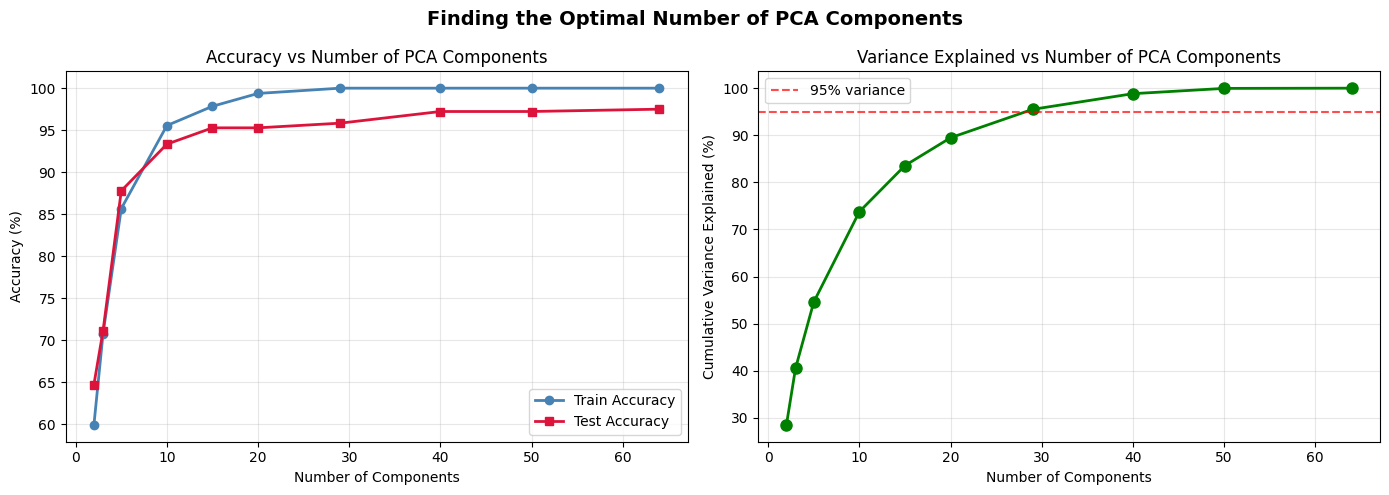

In [18]:
from sklearn.pipeline import Pipeline

# Test different numbers of components
# 🔁 Change this range to explore more options
n_components_range = [2, 3, 5, 10, 15, 20, 29, 40, 50, 64]
results = []

print("Testing different numbers of PCA components...")
print(f"{'n_components':>12} | {'Variance %':>10} | {'Train Acc':>10} | {'Test Acc':>10}")
print("-" * 50)

for n in n_components_range:
    # Use a Pipeline to chain PCA → LogisticRegression cleanly
    if n < 64:
        pipeline = Pipeline([
            ('pca', PCA(n_components=n)),
            ('clf', LogisticRegression(max_iter=1000, random_state=42))
        ])
    else:
        # No PCA for 64D — use original data directly
        pipeline = Pipeline([
            ('clf', LogisticRegression(max_iter=1000, random_state=42))
        ])

    pipeline.fit(X_train, y_train)
    train_acc = pipeline.score(X_train, y_train)
    test_acc  = pipeline.score(X_test, y_test)

    # Get variance explained for PCA models
    if n < 64:
        var_pct = pipeline.named_steps['pca'].explained_variance_ratio_.sum() * 100
    else:
        var_pct = 100.0

    results.append({'n': n, 'var': var_pct, 'train_acc': train_acc, 'test_acc': test_acc})
    print(f"{n:>12} | {var_pct:>9.1f}% | {train_acc*100:>9.2f}% | {test_acc*100:>9.2f}%")

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ns     = [r['n'] for r in results]
vars_  = [r['var'] for r in results]
trains = [r['train_acc']*100 for r in results]
tests  = [r['test_acc']*100 for r in results]

# Accuracy vs Components
axes[0].plot(ns, trains, 'o-', label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(ns, tests, 's-', label='Test Accuracy', color='crimson', linewidth=2)
axes[0].set_title('Accuracy vs Number of PCA Components', fontsize=12)
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Variance vs Components
axes[1].plot(ns, vars_, 'o-', color='green', linewidth=2, markersize=8)
axes[1].axhline(y=95, color='red', linestyle='--', alpha=0.7, label='95% variance')
axes[1].set_title('Variance Explained vs Number of PCA Components', fontsize=12)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Finding the Optimal Number of PCA Components', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🖼️ Step 11: Reconstruct Digit Images After Compression

Let's visually see the quality of reconstructed digit images at different compression levels.

This is like comparing JPEG image quality at different compression settings.

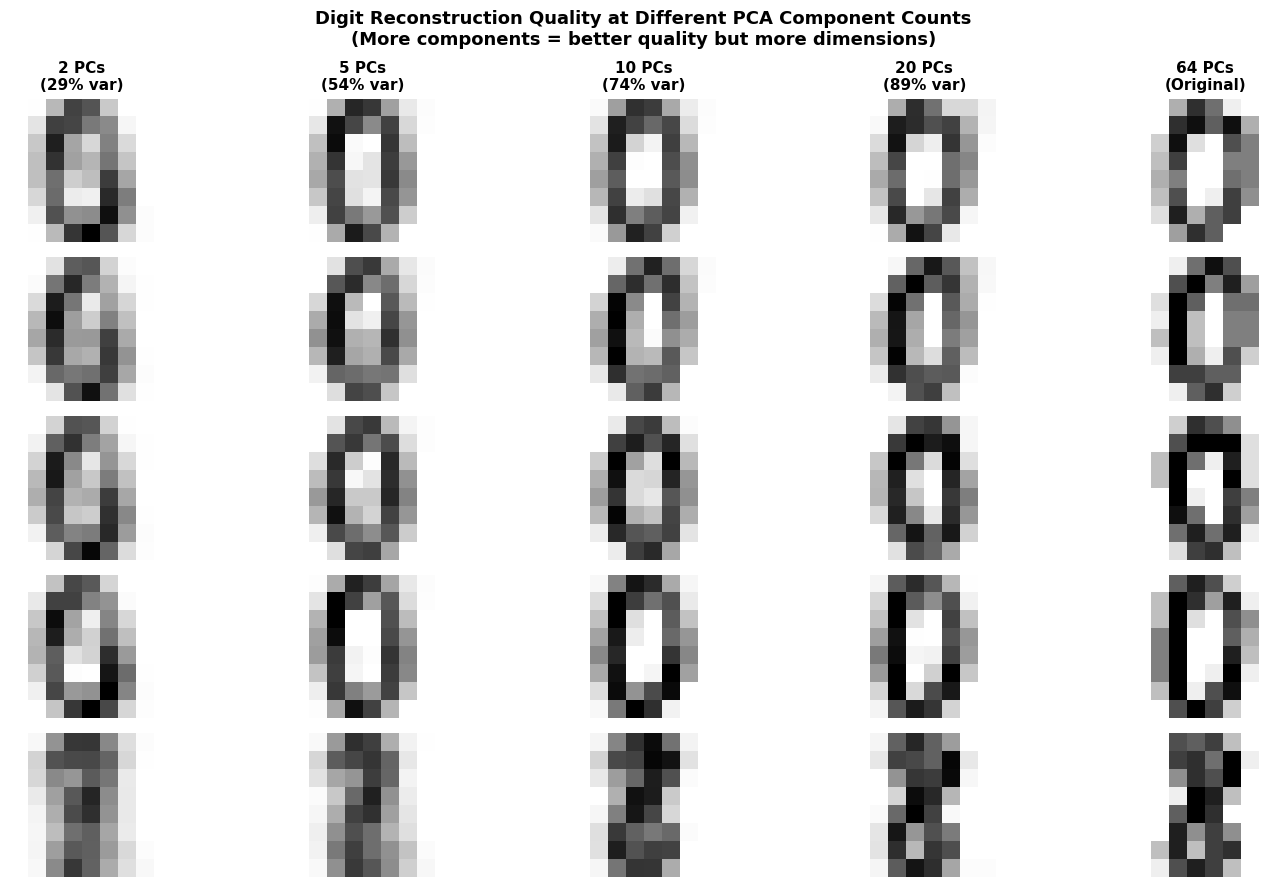

📌 Observations:
  • 2 components: Very blurry, barely recognizable
  • 5 components: Rough shape visible
  • 10 components: Much more recognizable
  • 20 components: Near-original quality
  • 64 components: Perfect (original image)

💡 For most ML tasks, 20-30 components give excellent results
   while providing meaningful compression!


In [19]:
# Show original vs reconstructed digits at different compression levels
sample_indices = [0, 10, 20, 30, 40]  # Pick 5 sample digits to visualize
component_levels = [2, 5, 10, 20, 64]  # Different compression levels

fig, axes = plt.subplots(
    len(sample_indices), len(component_levels),
    figsize=(15, 9)
)

fig.suptitle('Digit Reconstruction Quality at Different PCA Component Counts\n'
             '(More components = better quality but more dimensions)',
             fontsize=13, fontweight='bold')

for col, n_comp in enumerate(component_levels):
    # Fit PCA and reconstruct
    if n_comp < 64:
        pca_temp = PCA(n_components=n_comp)
        X_compressed_temp = pca_temp.fit_transform(X_digits)
        X_reconstructed_temp = pca_temp.inverse_transform(X_compressed_temp)
        var_explained = pca_temp.explained_variance_ratio_.sum() * 100
        title = f'{n_comp} PCs\n({var_explained:.0f}% var)'
    else:
        X_reconstructed_temp = X_digits  # Original = 64 components
        title = f'64 PCs\n(Original)'

    for row, idx in enumerate(sample_indices):
        ax = axes[row][col]
        img = np.clip(X_reconstructed_temp[idx].reshape(8, 8), 0, 16)
        ax.imshow(img, cmap='gray_r', interpolation='nearest', vmin=0, vmax=16)
        ax.axis('off')

        if row == 0:
            ax.set_title(title, fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'Digit {y_digits[idx]}', rotation=0, labelpad=30, fontsize=10)

plt.tight_layout()
plt.show()

print("📌 Observations:")
print("  • 2 components: Very blurry, barely recognizable")
print("  • 5 components: Rough shape visible")
print("  • 10 components: Much more recognizable")
print("  • 20 components: Near-original quality")
print("  • 64 components: Perfect (original image)")
print()
print("💡 For most ML tasks, 20-30 components give excellent results")
print("   while providing meaningful compression!")

---
## 📊 Step 12: The Cumulative Explained Variance Plot — Your Guide to Choosing Components

This is one of the most important plots in PCA. It helps you decide **how many components to keep**.

### How to Read It:
- **X-axis**: Number of principal components
- **Y-axis**: Cumulative % of variance explained
- **Look for the "elbow"**: The point where the curve starts to flatten — adding more components gives diminishing returns
- **Common thresholds**: 95% or 99% variance retained

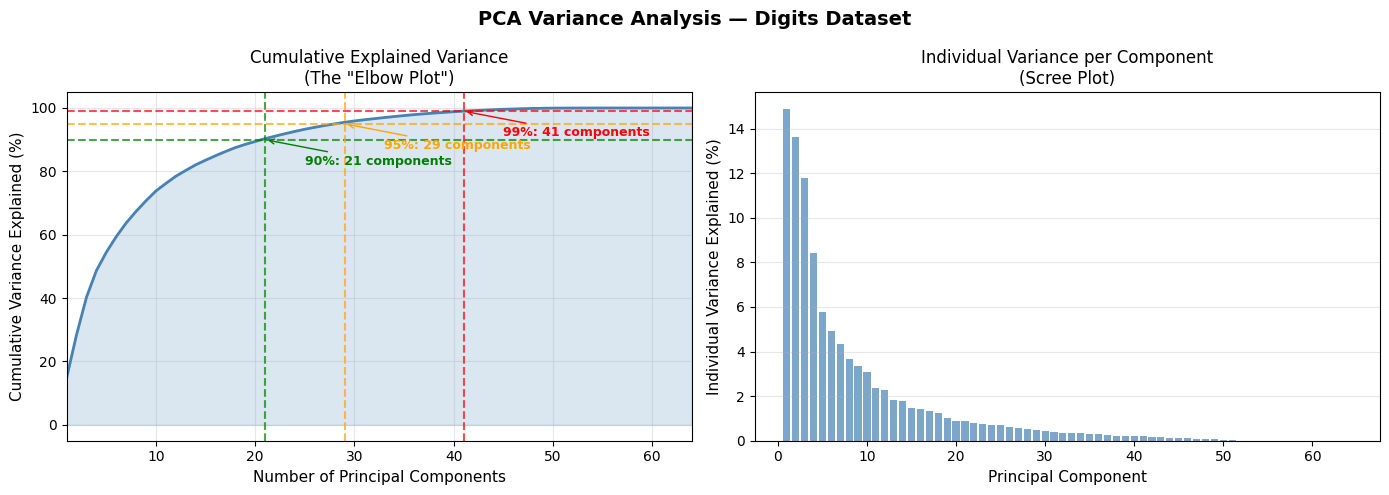

✅ Decision Guide:
  Keep 21 components → retain 90% of variance (3.0× compression)
  Keep 29 components → retain 95% of variance (2.2× compression)
  Keep 41 components → retain 99% of variance (1.6× compression)


In [20]:
# Fit PCA with ALL 64 components to get the full variance picture
pca_full = PCA(n_components=64)
pca_full.fit(X_digits)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100
individual_variance = pca_full.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Cumulative explained variance ──
axes[0].plot(range(1, 65), cumulative_variance, color='steelblue', linewidth=2)
axes[0].fill_between(range(1, 65), cumulative_variance, alpha=0.2, color='steelblue')

# Mark key thresholds
for threshold, color, label in [(90, 'green', '90%'), (95, 'orange', '95%'), (99, 'red', '99%')]:
    idx = np.argmax(cumulative_variance >= threshold)
    axes[0].axhline(y=threshold, color=color, linestyle='--', alpha=0.7)
    axes[0].axvline(x=idx+1, color=color, linestyle='--', alpha=0.7)
    axes[0].annotate(f'{label}: {idx+1} components', 
                     xy=(idx+1, threshold), xytext=(idx+5, threshold-8),
                     color=color, fontsize=9, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=color))

axes[0].set_xlabel('Number of Principal Components', fontsize=11)
axes[0].set_ylabel('Cumulative Variance Explained (%)', fontsize=11)
axes[0].set_title('Cumulative Explained Variance\n(The "Elbow Plot")', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(1, 64)

# ── Plot 2: Individual variance per component ──
axes[1].bar(range(1, 65), individual_variance, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Principal Component', fontsize=11)
axes[1].set_ylabel('Individual Variance Explained (%)', fontsize=11)
axes[1].set_title('Individual Variance per Component\n(Scree Plot)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('PCA Variance Analysis — Digits Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Decision Guide:")
for threshold in [90, 95, 99]:
    idx = np.argmax(cumulative_variance >= threshold)
    print(f"  Keep {idx+1:2d} components → retain {threshold}% of variance ({X_digits.shape[1]/(idx+1):.1f}× compression)")

---
# 📚 Summary: Everything You Need to Know About PCA

## Core Concepts Recap

| Concept | What It Is | Why It Matters |
|---|---|---|
| **Principal Component** | A new axis/direction in data space | Defines the new coordinate system |
| **Explained Variance Ratio** | % of total variance captured by a component | Tells you how important each component is |
| **n_components** | How many PCs you keep | Controls the trade-off between compression and information |
| **Transformation** | Projecting data onto PCs | Converts original features to PC coordinates |
| **Inverse Transform** | Projecting back to original space | Reconstructs (approximate) original data |

## Key Rules of Thumb

1. **Choose n_components based on the elbow plot** — look for where the cumulative variance curve flattens
2. **For classification tasks**: 95% variance retention usually gives near-original accuracy
3. **For visualization**: Use 2 or 3 components regardless of information loss
4. **Always fit PCA on training data only** — never include test data in PCA fitting (data leakage!)
5. **Standardize features before PCA** if they have very different scales (e.g., use `StandardScaler`)

## When Does PCA Help Most?

✅ **PCA works great when:**
- Features are **correlated** with each other
- Dataset is **high-dimensional** (images, text embeddings, sensor data)
- You need to **visualize** high-D data
- Training is **slow** due to too many features

❌ **PCA may not help when:**
- Features are already **independent** and uncorrelated
- You need **interpretable** features (PCs are linear combinations, hard to explain)
- The data has **non-linear** structure (use t-SNE or UMAP instead)

## Other Dimensionality Reduction Methods

| Method | Best For | Notes |
|---|---|---|
| **PCA** | Linear data, speed, preprocessing | Fast, deterministic, good all-rounder |
| **t-SNE** | Visualization of clusters | Slow, non-linear, great for 2D/3D plots |
| **UMAP** | Large-scale visualization | Faster than t-SNE, preserves global structure |
| **LDA** | Supervised reduction | Uses class labels to maximize class separation |
| **Autoencoder** | Non-linear, deep learning | Most powerful but needs training |

## 🔁 Things to Experiment With

1. Change `n_components` in PCA and observe accuracy
2. Try `n_components=0.95` to automatically keep 95% variance
3. Add `StandardScaler()` before PCA and see if accuracy changes
4. Replace `LogisticRegression` with `RandomForestClassifier` — does PCA help more or less?
5. Try the same PCA approach on the `load_wine()` or `load_breast_cancer()` datasets

In [21]:
# BONUS: Compare PCA with and without StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("=" * 60)
print("BONUS: Does Standardization Before PCA Help?")
print("=" * 60)
print()
print("StandardScaler centers each feature to mean=0, std=1")
print("This prevents high-magnitude features from dominating PCA")
print()

results_scaling = {}
for n in [3, 10, 29]:
    # Without scaling
    pipe_no_scale = Pipeline([
        ('pca', PCA(n_components=n)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
    pipe_no_scale.fit(X_train, y_train)
    acc_no_scale = pipe_no_scale.score(X_test, y_test)

    # With scaling
    pipe_scaled = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
    pipe_scaled.fit(X_train, y_train)
    acc_scaled = pipe_scaled.score(X_test, y_test)

    print(f"n_components={n:2d}:  Without scaling: {acc_no_scale*100:.2f}%  |  With scaling: {acc_scaled*100:.2f}%  |  Δ = {(acc_scaled-acc_no_scale)*100:+.2f}%")

print()
print("💡 For the digits dataset, pixels already have similar scales (0-16)")
print("   so scaling doesn't help much. For mixed-scale data (e.g., age + income),")
print("   standardizing BEFORE PCA is crucial!")

BONUS: Does Standardization Before PCA Help?

StandardScaler centers each feature to mean=0, std=1
This prevents high-magnitude features from dominating PCA

n_components= 3:  Without scaling: 71.11%  |  With scaling: 67.78%  |  Δ = -3.33%
n_components=10:  Without scaling: 93.33%  |  With scaling: 88.61%  |  Δ = -4.72%
n_components=29:  Without scaling: 95.83%  |  With scaling: 95.83%  |  Δ = +0.00%

💡 For the digits dataset, pixels already have similar scales (0-16)
   so scaling doesn't help much. For mixed-scale data (e.g., age + income),
   standardizing BEFORE PCA is crucial!


---
# 🏁 You've Completed the Dimensionality Reduction Notebook!

### What You Learned:
- ✅ Why high-dimensional data is problematic (Curse of Dimensionality)
- ✅ How PCA works step by step (centering, covariance, eigenvectors)
- ✅ How to interpret explained variance ratio and choose the right number of components
- ✅ What principal component vectors look like as images
- ✅ How to compress and reconstruct data with PCA
- ✅ How to avoid data leakage (fit PCA on train only!)
- ✅ Trade-offs between compression level and classification accuracy
- ✅ When to standardize before PCA
